# 📈 Анализ S&P 500 с использованием Hadoop HDFS и PySpark

**Датасет:** [S&P 500 Stock Data — Kaggle](https://www.kaggle.com/datasets/camnugent/sandp500)  
**Столбцы:** `Date, Open, High, Low, Close, Volume, Name`  

Дата - в формате: гг-мм-дд

Дата открытия - цена акции на момент открытия рынка (это данные NYSE, поэтому все в долларах США)

High - максимальная цена, достигнутая за день

Low Close - минимальная цена, достигнутая за день

Volume - Количество проданных акций

Name - название биржевого тикера
**Объём:** ~600 000 строк, 505 компаний, 2013–2018 гг.

---
## Архитектура решения
```
 Источник данных            Hadoop HDFS                 PySpark
┌──────────────────┐       ┌─────────────────────────┐  ┌────────────────┐
│ Kaggle / yfinance│──────▶│ hdfs://localhost:9000   │─▶│ DataFrame API  │
│ all_stocks_5yr   │  put  │ /user/sp500/raw/        │  │ PySpark SQL    │──▶ Визуализации
│    .csv          │       │ /user/sp500/results/    │  │ Window Funcs   │
└──────────────────┘       └─────────────────────────┘  └────────────────┘
```

**Выполняемые задачи:**
1. Установка и настройка Hadoop HDFS в режиме псевдораспределения
2. Загрузка данных в HDFS
3. Обработка и анализ данных с помощью PySpark / PySpark SQL
4. Выявление тенденций и закономерностей
5. Визуализация (6 графиков)
6. Сохранение результатов в HDFS (Parquet + CSV)
7. Автоматизация через bash-скрипт


## 1. Установка зависимостей

In [ ]:
# Устанавливаем Java, PySpark и вспомогательные библиотеки
import subprocess, sys, os

pkgs = ["pyspark==3.5.1", "hdfs", "yfinance==0.2.40", "seaborn", "scipy"]
subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkgs, check=True)

# Java (обычно уже установлена в Colab)
JAVA_CANDIDATES = [
    "/usr/lib/jvm/java-11-openjdk-amd64",
    "/usr/lib/jvm/java-17-openjdk-amd64",
    "/usr/lib/jvm/temurin-11-jdk-amd64",
]
JAVA_HOME = next((p for p in JAVA_CANDIDATES if os.path.isdir(p)), None)
if not JAVA_HOME:
    subprocess.run(["apt-get", "install", "-y", "-q", "openjdk-11-jdk-headless"], check=True)
    JAVA_HOME = "/usr/lib/jvm/java-11-openjdk-amd64"

os.environ["JAVA_HOME"] = JAVA_HOME
print(f"✅ JAVA_HOME = {JAVA_HOME}")
print("✅ Все зависимости установлены")


✅ JAVA_HOME = /usr/lib/jvm/java-17-openjdk-amd64
✅ Все зависимости установлены


## 2. Установка и настройка Hadoop HDFS

In [ ]:
import os, subprocess, pathlib

HADOOP_VERSION = "3.3.6"
HADOOP_HOME    = f"/opt/hadoop-{HADOOP_VERSION}"
HADOOP_URL     = (
    f"https://archive.apache.org/dist/hadoop/common/"
    f"hadoop-{HADOOP_VERSION}/hadoop-{HADOOP_VERSION}.tar.gz"
)

if not os.path.isdir(HADOOP_HOME):
    print("⬇️  Загружаем Hadoop (~750 МБ) — это займёт несколько минут...")
    subprocess.run(
        ["wget", "-q", "--show-progress", "-O", "/tmp/hadoop.tar.gz", HADOOP_URL],
        check=True
    )
    subprocess.run(["tar", "-xzf", "/tmp/hadoop.tar.gz", "-C", "/opt/"], check=True)
    print("✅ Hadoop распакован")
else:
    print(f"✅ Hadoop уже установлен: {HADOOP_HOME}")

# Переменные окружения
os.environ.update({
    "HADOOP_HOME":                    HADOOP_HOME,
    "HADOOP_CONF_DIR":                f"{HADOOP_HOME}/etc/hadoop",
    "PATH":                           f"{HADOOP_HOME}/bin:{HADOOP_HOME}/sbin:{os.environ['PATH']}",
    "HADOOP_OPTS":                    f"-Djava.library.path={HADOOP_HOME}/lib/native",
    "HDFS_NAMENODE_USER":             "root",
    "HDFS_DATANODE_USER":             "root",
    "HDFS_SECONDARYNAMENODE_USER":    "root",
    "YARN_RESOURCEMANAGER_USER":      "root",
    "YARN_NODEMANAGER_USER":          "root",
})
print("✅ Переменные окружения настроены")


⬇️  Загружаем Hadoop (~750 МБ) — это займёт несколько минут...
✅ Hadoop распакован
✅ Переменные окружения настроены


In [ ]:
import os, pathlib

HADOOP_HOME = os.environ["HADOOP_HOME"]
HADOOP_CONF = f"{HADOOP_HOME}/etc/hadoop"
JAVA_HOME   = os.environ["JAVA_HOME"]

# --- hadoop-env.sh ---
env_sh   = pathlib.Path(f"{HADOOP_CONF}/hadoop-env.sh")
content  = env_sh.read_text()
env_line = f"export JAVA_HOME={JAVA_HOME}"
if env_line not in content:
    env_sh.write_text(content + f"\n{env_line}\n")

# --- core-site.xml ---
pathlib.Path(f"{HADOOP_CONF}/core-site.xml").write_text(
    '<?xml version="1.0" encoding="UTF-8"?>\n'
    '<configuration>\n'
    '  <property><name>fs.defaultFS</name><value>hdfs://localhost:9000</value></property>\n'
    '  <property><name>hadoop.tmp.dir</name><value>/tmp/hadoop-tmp</value></property>\n'
    '</configuration>\n'
)

# --- hdfs-site.xml ---
pathlib.Path(f"{HADOOP_CONF}/hdfs-site.xml").write_text(
    '<?xml version="1.0" encoding="UTF-8"?>\n'
    '<configuration>\n'
    '  <property><name>dfs.replication</name><value>1</value></property>\n'
    '  <property><name>dfs.namenode.name.dir</name><value>/tmp/hadoop-nn</value></property>\n'
    '  <property><name>dfs.datanode.data.dir</name><value>/tmp/hadoop-dn</value></property>\n'
    '  <property><name>dfs.permissions.enabled</name><value>false</value></property>\n'
    '  <property><name>dfs.webhdfs.enabled</name><value>true</value></property>\n'
    '</configuration>\n'
)

# --- mapred-site.xml ---
pathlib.Path(f"{HADOOP_CONF}/mapred-site.xml").write_text(
    '<?xml version="1.0" encoding="UTF-8"?>\n'
    '<configuration>\n'
    '  <property><name>mapreduce.framework.name</name><value>local</value></property>\n'
    '</configuration>\n'
)

print("✅ Конфигурационные файлы Hadoop записаны")


✅ Конфигурационные файлы Hadoop записаны


In [ ]:
import subprocess, os, time

HADOOP_HOME = os.environ["HADOOP_HOME"]
env         = dict(os.environ)

def hdfs_cmd(cmd, capture=True):
    return subprocess.run(
        f"{HADOOP_HOME}/bin/hdfs dfs {cmd}",
        shell=True, capture_output=capture, text=True, env=env
    )

# Сброс данных предыдущего запуска
for d in ["/tmp/hadoop-tmp", "/tmp/hadoop-nn", "/tmp/hadoop-dn"]:
    subprocess.run(f"rm -rf {d}", shell=True)

# Форматирование NameNode
print("🔧 Форматируем NameNode...")
r = subprocess.run(
    f"{HADOOP_HOME}/bin/hdfs namenode -format -force",
    shell=True, capture_output=True, text=True, env=env
)
print("✅ NameNode отформатирован" if r.returncode == 0
      else f"⚠️ Ошибка форматирования: {r.stderr[-300:]}")

# Запуск HDFS
print("🚀 Запускаем HDFS...")
subprocess.Popen(
    f"{HADOOP_HOME}/sbin/start-dfs.sh",
    shell=True, env=env,
    stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL
)
time.sleep(14)

# Проверка
r = hdfs_cmd("-ls /")
if r.returncode == 0:
    print("✅ HDFS запущен и доступен!")
    print(r.stdout or "(корень пуст, это нормально)")
else:
    print(f"⚠️  Ещё стартует или ошибка: {r.stderr[-200:]}")


🔧 Форматируем NameNode...
✅ NameNode отформатирован
🚀 Запускаем HDFS...
⚠️  Ещё стартует или ошибка: l From 2dd71d41fc2e/172.28.0.12 to localhost:9000 failed on connection exception: java.net.ConnectException: Connection refused; For more details see:  http://wiki.apache.org/hadoop/ConnectionRefused



## 3. Загрузка данных S&P 500

In [ ]:
import os
import gdown

def download_from_google_drive(share_link, output_path):
    """
    Скачивает файл с Google Диска по полной ссылке.
    """
    try:
        # Извлекаем ID из ссылки и скачиваем
        gdown.download(share_link, output_path, quiet=False, fuzzy=True)
        return os.path.exists(output_path)
    except Exception as e:
        print(f"❌ Ошибка скачивания: {e}")
        return False

LOCAL_CSV = "/tmp/all_stocks_5yr.csv"

if not os.path.exists(LOCAL_CSV):
    print("📥 Скачиваем файл с Google Диска...")
    # Указываем вашу полную ссылку
    success = download_from_google_drive(
        "https://drive.google.com/file/d/1CYr_quGr8dA9usYgxFHTB3E1ny2it9Dy/view",
        LOCAL_CSV
    )
    if not success:
        print("Не удалось загрузить файл. Проверьте ссылку.")
        exit(1)
else:
    print(f"✅ CSV уже существует: {LOCAL_CSV}")

📥 Скачиваем файл с Google Диска...


Downloading...
From: https://drive.google.com/uc?id=1CYr_quGr8dA9usYgxFHTB3E1ny2it9Dy
To: /tmp/all_stocks_5yr.csv
100%|██████████| 29.6M/29.6M [00:00<00:00, 43.8MB/s]


## 4. Загрузка данных в HDFS

In [ ]:
import subprocess, os, time, sys

# Установка Java 11 и Hadoop
!apt-get update -qq
!apt-get install -y openjdk-11-jdk-headless ssh pdsh -qq

# Установка Hadoop
!wget -q https://archive.apache.org/dist/hadoop/common/hadoop-3.3.6/hadoop-3.3.6.tar.gz
!tar -xzf hadoop-3.3.6.tar.gz
!mv hadoop-3.3.6 /usr/local/hadoop

# Настройка JAVA_HOME
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["HADOOP_HOME"] = "/usr/local/hadoop"
os.environ["PATH"] += f":{os.environ['HADOOP_HOME']}/bin:{os.environ['HADOOP_HOME']}/sbin"
os.environ["HADOOP_CONF_DIR"] = f"{os.environ['HADOOP_HOME']}/etc/hadoop"

# Настройка SSH для localhost (необходимо для start-dfs.sh)
!ssh-keygen -t rsa -P '' -f ~/.ssh/id_rsa
!cat ~/.ssh/id_rsa.pub >> ~/.ssh/authorized_keys
!chmod 600 ~/.ssh/authorized_keys
!service ssh start

# Конфигурационные файлы
conf_dir = f"{os.environ['HADOOP_HOME']}/etc/hadoop"
with open(f"{conf_dir}/core-site.xml", "w") as f:
    f.write("""<?xml version="1.0" encoding="UTF-8"?>
<configuration>
  <property><name>fs.defaultFS</name><value>hdfs://localhost:9000</value></property>
</configuration>""")
with open(f"{conf_dir}/hdfs-site.xml", "w") as f:
    f.write("""<?xml version="1.0" encoding="UTF-8"?>
<configuration>
  <property><name>dfs.replication</name><value>1</value></property>
  <property><name>dfs.namenode.name.dir</name><value>/tmp/hadoop/namenode</value></property>
  <property><name>dfs.datanode.data.dir</name><value>/tmp/hadoop/datanode</value></property>
</configuration>""")

# Форматирование NameNode
!echo Y | hdfs namenode -format

# Запуск демонов вручную (без start-dfs.sh, который может требовать пароль)
!$HADOOP_HOME/bin/hdfs --daemon start namenode
!$HADOOP_HOME/bin/hdfs --daemon start datanode
time.sleep(5)

# Проверка статуса
!jps
!netstat -tulpn | grep 9000

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Preconfiguring packages ...
Selecting previously unselected package ssh.
(Reading database ... 118718 files and directories currently installed.)
Preparing to unpack .../ssh_1%3a8.9p1-3ubuntu0.15_all.deb ...
Unpacking ssh (1:8.9p1-3ubuntu0.15) ...
Selecting previously unselected package libgenders0:amd64.
Preparing to unpack .../libgenders0_1.22-1build4_amd64.deb ...
Unpacking libgenders0:amd64 (1.22-1build4) ...
Selecting previously unselected package genders.
Preparing to unpack .../genders_1.22-1build4_amd64.deb ...
Unpacking genders (1.22-1build4) ...
Selecting previously unselected package pdsh.
Preparing to unpack .../pdsh_2.31-3build2_amd64.deb ...
Unpacking pdsh (2.31-3build2) ...
Setting up libgenders0:amd64 (1.22-1build4) ...
Setting up ssh (1:8.9p1-3ubuntu0.15) ...
Setting up genders (1.22

In [ ]:
# ============================================================
# 4. Скачивание файла с Google Диска
# ============================================================
import gdown

FILE_ID = "1CYr_quGr8dA9usYgxFHTB3E1ny2it9Dy"
LOCAL_CSV = "/tmp/all_stocks_5yr.csv"

if not os.path.exists(LOCAL_CSV):
    print("📥 Скачивание с Google Диска...")
    gdown.download(id=FILE_ID, output=LOCAL_CSV, quiet=False)
    print("✅ Файл загружен")
else:
    print(f"✅ Файл уже существует: {LOCAL_CSV}")

# ============================================================
# 5. Ваш код работы с HDFS (полностью сохранён)
# ============================================================
HADOOP_HOME = os.environ["HADOOP_HOME"]
HDFS_RAW = "/user/sp500/raw"
HDFS_RESULTS = "/user/sp500/results"
env = dict(os.environ)

def hdfs(cmd):
    r = subprocess.run(
        f"{HADOOP_HOME}/bin/hdfs dfs {cmd}",
        shell=True, capture_output=True, text=True, env=env
    )
    return r.returncode == 0, r.stdout, r.stderr

# Создаём директории в HDFS
for d in [HDFS_RAW, HDFS_RESULTS, f"{HDFS_RESULTS}/plots"]:
    hdfs(f"-mkdir -p {d}")
    print(f"📁 Создана HDFS-директория: {d}")

# Удаляем старый файл, если есть
hdfs(f"-rm -f {HDFS_RAW}/all_stocks_5yr.csv")

# Загружаем CSV в HDFS
ok, out, err = hdfs(f"-put {LOCAL_CSV} {HDFS_RAW}/")
print("✅ Файл загружен в HDFS" if ok else f"❌ Ошибка: {err}")

# Проверяем содержимое HDFS
ok, out, err = hdfs(f"-ls -h {HDFS_RAW}")
print("\n📂 Содержимое HDFS:")
print(out if ok else err)

# Показываем первые строки файла из HDFS
ok, out, err = hdfs(f"-cat {HDFS_RAW}/all_stocks_5yr.csv")
if ok:
    lines = out.strip().split("\n")
    print(f"\n📋 Первые 3 строки из HDFS:")
    for l in lines[:3]:
        print(" ", l)
else:
    print(f"❌ Не удалось прочитать файл: {err}")

✅ Файл уже существует: /tmp/all_stocks_5yr.csv
📁 Создана HDFS-директория: /user/sp500/raw
📁 Создана HDFS-директория: /user/sp500/results
📁 Создана HDFS-директория: /user/sp500/results/plots
✅ Файл загружен в HDFS

📂 Содержимое HDFS:
Found 1 items
-rw-r--r--   1 root supergroup     28.2 M 2026-06-01 20:42 /user/sp500/raw/all_stocks_5yr.csv


📋 Первые 3 строки из HDFS:
  date,open,high,low,close,volume,Name
  2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
  2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL


## 5. Инициализация PySpark

In [ ]:
import os
from pyspark.sql import SparkSession
from pyspark import SparkConf

os.environ["PYSPARK_PYTHON"]        = "python3"
os.environ["PYSPARK_DRIVER_PYTHON"] = "python3"

conf = (SparkConf()
    .setAppName("SP500_Analysis")
    .setMaster("local[*]")
    .set("spark.driver.memory",            "4g")
    .set("spark.executor.memory",          "2g")
    .set("spark.sql.adaptive.enabled",     "true")
    .set("spark.sql.shuffle.partitions",   "8")
    .set("spark.hadoop.fs.defaultFS",      "hdfs://localhost:9000")
)

spark = (SparkSession.builder
    .config(conf=conf)
    .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

print(f"✅ SparkSession запущен (Spark {spark.version})")
print(f"   Master:  {spark.conf.get('spark.master')}")
print(f"   App:     {spark.conf.get('spark.app.name')}")
print(f"   UI:      http://localhost:4040")


✅ SparkSession запущен (Spark 3.5.1)
   Master:  local[*]
   App:     SP500_Analysis
   UI:      http://localhost:4040


## 6. Загрузка и очистка данных

In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.types import StructType, StructField, StringType, DoubleType, LongType

HDFS_RAW = "hdfs://localhost:9000/user/sp500/raw/all_stocks_5yr.csv"

# Читаем из HDFS
df_raw = (spark.read
    .option("header",       "true")
    .option("inferSchema",  "true")
    .csv(HDFS_RAW))

# Унифицируем имена столбцов
df_raw = df_raw.toDF(*[c.lower() for c in df_raw.columns])

print("📐 Схема датафрейма:")
df_raw.printSchema()
print(f"Строк: {df_raw.count():,}   Столбцов: {len(df_raw.columns)}")
df_raw.show(5)


📐 Схема датафрейма:
root
 |-- date: date (nullable = true)
 |-- open: double (nullable = true)
 |-- high: double (nullable = true)
 |-- low: double (nullable = true)
 |-- close: double (nullable = true)
 |-- volume: integer (nullable = true)
 |-- name: string (nullable = true)

Строк: 619,040   Столбцов: 7
+----------+-----+-----+-----+-----+--------+----+
|      date| open| high|  low|close|  volume|name|
+----------+-----+-----+-----+-----+--------+----+
|2013-02-08|15.07|15.12|14.63|14.75| 8407500| AAL|
|2013-02-11|14.89|15.01|14.26|14.46| 8882000| AAL|
|2013-02-12|14.45|14.51| 14.1|14.27| 8126000| AAL|
|2013-02-13| 14.3|14.94|14.25|14.66|10259500| AAL|
|2013-02-14|14.94|14.96|13.16|13.99|31879900| AAL|
+----------+-----+-----+-----+-----+--------+----+
only showing top 5 rows



In [ ]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Очистка и обогащение данных
df = (df_raw
    .withColumn("date",         F.to_date("date", "yyyy-MM-dd"))
    .withColumn("year",         F.year("date"))
    .withColumn("month",        F.month("date"))
    .withColumn("quarter",      F.quarter("date"))
    # Дневная доходность в %
    .withColumn("daily_return",
        F.round((F.col("close") - F.col("open")) / F.col("open") * 100, 4))
    # Дневной диапазон цены
    .withColumn("price_range",  F.round(F.col("high") - F.col("low"), 4))
    # Признак роста за день
    .withColumn("is_up_day",    (F.col("close") > F.col("open")).cast("integer"))
    .dropna(subset=["date", "close", "name"])
    .filter(F.col("close") > 0)
    .filter(F.col("volume") > 0)
)

# Регистрируем для SQL
df.createOrReplaceTempView("sp500")

print(f"✅ Данные очищены")
print(f"   Строк:    {df.count():,}")
print(f"   Тикеров:  {df.select('name').distinct().count()}")
print(f"   Период:   {df.agg(F.min('date')).collect()[0][0]} — {df.agg(F.max('date')).collect()[0][0]}")
df.show(5)


✅ Данные очищены
   Строк:    619,036
   Тикеров:  505
   Период:   2013-02-08 — 2018-02-07
+----------+-----+-----+-----+-----+--------+----+----+-----+-------+------------+-----------+---------+
|      date| open| high|  low|close|  volume|name|year|month|quarter|daily_return|price_range|is_up_day|
+----------+-----+-----+-----+-----+--------+----+----+-----+-------+------------+-----------+---------+
|2013-02-08|15.07|15.12|14.63|14.75| 8407500| AAL|2013|    2|      1|     -2.1234|       0.49|        0|
|2013-02-11|14.89|15.01|14.26|14.46| 8882000| AAL|2013|    2|      1|     -2.8878|       0.75|        0|
|2013-02-12|14.45|14.51| 14.1|14.27| 8126000| AAL|2013|    2|      1|     -1.2457|       0.41|        0|
|2013-02-13| 14.3|14.94|14.25|14.66|10259500| AAL|2013|    2|      1|      2.5175|       0.69|        1|
|2013-02-14|14.94|14.96|13.16|13.99|31879900| AAL|2013|    2|      1|     -6.3588|        1.8|        0|
+----------+-----+-----+-----+-----+--------+----+----+-----+-------

## 7. Анализ данных с помощью PySpark SQL

In [ ]:
# ── 7.1 Годовая доходность и волатильность рынка ────────────────────────────
print("=" * 62)
print("📊 7.1  Средняя дневная доходность и волатильность по годам")
print("=" * 62)

yearly_market = spark.sql("""
    SELECT
        year,
        ROUND(AVG(daily_return), 4)                    AS avg_daily_return_pct,
        ROUND(STDDEV(daily_return), 4)                 AS volatility_pct,
        ROUND(AVG(volume) / 1e6, 2)                    AS avg_volume_mln,
        ROUND(SUM(is_up_day) * 100.0 / COUNT(*), 1)   AS win_rate_pct,
        COUNT(DISTINCT name)                           AS companies_count,
        COUNT(*)                                       AS total_trading_days
    FROM sp500
    GROUP BY year
    ORDER BY year
""")

# Переименовываем столбцы на русские названия
yearly_market_rus = yearly_market.select(
    yearly_market["year"].alias("год"),
    yearly_market["avg_daily_return_pct"].alias("ср. дневная доходность, %"),
    yearly_market["volatility_pct"].alias("волатильность, %"),
    yearly_market["avg_volume_mln"].alias("ср. объём, млн"),
    yearly_market["win_rate_pct"].alias("доля прибыльных дней, %"),
    yearly_market["companies_count"].alias("число компаний"),
    yearly_market["total_trading_days"].alias("всего торговых дней")
)

yearly_market_rus.show()


📊 7.1  Средняя дневная доходность и волатильность по годам
+----+-------------------------+----------------+--------------+-----------------------+--------------+-------------------+
| год|ср. дневная доходность, %|волатильность, %|ср. объём, млн|доля прибыльных дней, %|число компаний|всего торговых дней|
+----+-------------------------+----------------+--------------+-----------------------+--------------+-------------------+
|2013|                   0.0606|          1.2305|          4.57|                   52.2|           483|             108438|
|2014|                   0.0217|          1.2473|          4.16|                   51.5|           488|             122397|
|2015|                    0.006|           1.411|          4.32|                   50.5|           495|             123719|
|2016|                   0.0715|          1.5054|          4.56|                   52.3|           499|             125320|
|2017|                   0.0229|          1.1519|          3.97|         

In [ ]:
# ── 7.2 ТОП-20 компаний по средней доходности ───────────────────────────────
print("=" * 62)
print("🏆 7.2  ТОП-20 компаний по средней дневной доходности")
print("=" * 62)

top_performers = spark.sql("""
    SELECT
        name,
        ROUND(AVG(daily_return), 4)                    AS avg_daily_return_pct,
        ROUND(STDDEV(daily_return), 4)                 AS volatility_pct,
        ROUND(SUM(volume) / 1e9, 3)                    AS total_volume_bln,
        COUNT(*)                                       AS trading_days,
        SUM(is_up_day)                                 AS up_days,
        ROUND(SUM(is_up_day) * 100.0 / COUNT(*), 1)   AS win_rate_pct
    FROM sp500
    GROUP BY name
    ORDER BY avg_daily_return_pct DESC
    LIMIT 20
""")

# Переименовываем столбцы на русский язык
top_performers_rus = top_performers.toDF(
    "тикер",
    "средняя доходность, %",
    "волатильность, %",
    "общий объём, млрд",
    "торговых дней",
    "дней роста",
    "процент успеха, %"
)

top_performers_rus.show(truncate=False)


🏆 7.2  ТОП-20 компаний по средней дневной доходности
+-----+---------------------+----------------+-----------------+-------------+----------+-----------------+
|тикер|средняя доходность, %|волатильность, %|общий объём, млрд|торговых дней|дней роста|процент успеха, %|
+-----+---------------------+----------------+-----------------+-------------+----------+-----------------+
|HPE  |0.1915               |1.823           |6.777            |581          |315       |54.2             |
|HPQ  |0.191                |1.7418          |7.308            |581          |318       |54.7             |
|INFO |0.1387               |1.2863          |1.321            |917          |499       |54.4             |
|BBY  |0.128                |1.8167          |7.19             |1259         |669       |53.1             |
|NVDA |0.1236               |1.7017          |13.176           |1259         |666       |52.9             |
|HUM  |0.1142               |1.5672          |1.815            |1259         |669  

In [ ]:
# ── 7.3 Квартальная сезонность ───────────────────────────────────────────────
print("=" * 62)
print("📅 7.3  Квартальная доходность (для тепловой карты)")
print("=" * 62)

quarterly = spark.sql("""
    SELECT
        year,
        quarter,
        ROUND(AVG(daily_return), 4)    AS avg_return_pct,
        ROUND(STDDEV(daily_return), 4) AS volatility_pct,
        COUNT(*)                       AS obs
    FROM sp500
    GROUP BY year, quarter
    ORDER BY year, quarter
""")

# Переименовываем столбцы на русский язык
quarterly_rus = quarterly.toDF(
    "год",
    "квартал",
    "средняя доходность, %",
    "волатильность, %",
    "наблюдений"
)
quarterly_rus.show(20)

# ── 7.4 Топ объёмов торгов ───────────────────────────────────────────────────
print("=" * 62)
print("💹 7.4  ТОП-10 компаний по среднедневному объёму торгов")
print("=" * 62)

volume_leaders = spark.sql("""
    SELECT
        name,
        ROUND(AVG(volume) / 1e6, 2)         AS avg_daily_vol_mln,
        ROUND(SUM(volume) / 1e9, 2)         AS total_volume_bln,
        ROUND(AVG(close), 2)                AS avg_close_price,
        ROUND(AVG(volume * close) / 1e9, 3) AS avg_daily_turnover_bln
    FROM sp500
    GROUP BY name
    ORDER BY avg_daily_vol_mln DESC
    LIMIT 10
""")

# Переименовываем столбцы на русский язык
volume_leaders_rus = volume_leaders.toDF(
    "тикер",
    "средний дневной объём, млн",
    "общий объём, млрд",
    "средняя цена закрытия",
    "ср. дневной оборот, млрд"
)
volume_leaders_rus.show(truncate=False)


📅 7.3  Квартальная доходность (для тепловой карты)
+----+-------+---------------------+----------------+----------+
| год|квартал|средняя доходность, %|волатильность, %|наблюдений|
+----+-------+---------------------+----------------+----------+
|2013|      1|               0.1068|          1.2196|     16184|
|2013|      2|               0.0234|          1.3534|     30539|
|2013|      3|               0.0384|           1.142|     30837|
|2013|      4|               0.0953|          1.1916|     30878|
|2014|      1|              -0.0133|          1.2838|     29466|
|2014|      2|               0.0419|          1.2465|     30548|
|2014|      3|              -0.0105|          1.0255|     31151|
|2014|      4|                0.067|          1.4031|     31232|
|2015|      1|               0.0545|          1.3521|     29799|
|2015|      2|               -0.032|          1.0907|     30812|
|2015|      3|              -0.0908|          1.5477|     31484|
|2015|      4|               0.0939|   

In [ ]:
# ── 7.5 Волатильность и коэффициент Шарпа (упрощённый) ─────────────────────
print("=" * 62)
print("📉 7.5  Анализ волатильности")
print("=" * 62)

volatility_df = spark.sql("""
    SELECT
        name,
        ROUND(STDDEV(daily_return), 4)                               AS volatility_pct,
        ROUND(AVG(daily_return), 4)                                  AS avg_return_pct,
        ROUND(AVG(daily_return) / NULLIF(STDDEV(daily_return),0), 4) AS sharpe_like,
        COUNT(*) AS days
    FROM sp500
    GROUP BY name
    HAVING COUNT(*) > 200
    ORDER BY volatility_pct DESC
""")

# Переименовываем столбцы на русский язык
volatility_df_rus = volatility_df.toDF(
    "тикер",
    "волатильность, %",
    "средняя доходность, %",
    "коэфф. Шарпа (упрощ.)",
    "дней"
)

print("🔴 Наиболее волатильные:")
volatility_df_rus.show(5, truncate=False)

print("🟢 Наиболее стабильные:")
volatility_df_rus.orderBy("волатильность, %").show(5, truncate=False)

# ── 7.6 Месячная сезонность ───────────────────────────────────────────────────
print("=" * 62)
print("🗓️  7.6  Сезонность: средняя доходность по месяцам")
print("=" * 62)

seasonality = spark.sql("""
    SELECT
        month,
        ROUND(AVG(daily_return), 4)                  AS avg_return_pct,
        ROUND(STDDEV(daily_return), 4)               AS volatility_pct,
        ROUND(SUM(is_up_day)*100.0/COUNT(*), 1)      AS win_rate_pct
    FROM sp500
    GROUP BY month
    ORDER BY month
""")

# Переименовываем столбцы на русский язык
seasonality_rus = seasonality.toDF(
    "месяц",
    "средняя доходность, %",
    "волатильность, %",
    "процент успеха, %"
)
seasonality_rus.show()

📉 7.5  Анализ волатильности
🔴 Наиболее волатильные:
+-----+----------------+---------------------+---------------------+----+
|тикер|волатильность, %|средняя доходность, %|коэфф. Шарпа (упрощ.)|дней|
+-----+----------------+---------------------+---------------------+----+
|CHK  |3.6831          |-0.1993              |-0.0541              |1259|
|AMD  |2.9592          |0.0444               |0.015                |1259|
|FCX  |2.8763          |-0.0438              |-0.0152              |1259|
|INCY |2.6532          |0.0952               |0.0359               |1259|
|WMB  |2.5066          |0.0315               |0.0126               |1259|
+-----+----------------+---------------------+---------------------+----+
only showing top 5 rows

🟢 Наиболее стабильные:
+-----+----------------+---------------------+---------------------+----+
|тикер|волатильность, %|средняя доходность, %|коэфф. Шарпа (упрощ.)|дней|
+-----+----------------+---------------------+---------------------+----+
|PEP  |0.733

## 8. Скользящие средние (PySpark Window Functions)

In [ ]:
from pyspark.sql.window import Window
from pyspark.sql import functions as F

# Окна для скользящих средних
w20  = Window.partitionBy("name").orderBy("date").rowsBetween(-19, 0)
w50  = Window.partitionBy("name").orderBy("date").rowsBetween(-49, 0)
wlag = Window.partitionBy("name").orderBy("date")

df_ma = (df
    .withColumn("sma_20",     F.round(F.avg("close").over(w20), 2))
    .withColumn("sma_50",     F.round(F.avg("close").over(w50), 2))
    .withColumn("prev_close", F.lag("close", 1).over(wlag))
    .withColumn("pct_change",
        F.round((F.col("close") - F.col("prev_close")) / F.col("prev_close") * 100, 4))
    # Golden Cross: SMA20 пересекает SMA50 снизу вверх
    .withColumn("golden_cross",
        ((F.col("sma_20") > F.col("sma_50")) &
         (F.lag("sma_20", 1).over(wlag) <= F.lag("sma_50", 1).over(wlag))
        ).cast("integer"))
)

df_ma.cache()
df_ma.createOrReplaceTempView("sp500_ma")

print("✅ SMA-20 и SMA-50 рассчитаны (Window Functions)")
print("   Пример для AAPL:")
(df_ma
 .filter(F.col("name") == "AAPL")
 .select("date","close","sma_20","sma_50","pct_change","golden_cross")
 .orderBy("date")
 .show(8))


✅ SMA-20 и SMA-50 рассчитаны (Window Functions)
   Пример для AAPL:
+----------+-------+------+------+----------+------------+
|      date|  close|sma_20|sma_50|pct_change|golden_cross|
+----------+-------+------+------+----------+------------+
|2013-02-08|67.8542| 67.85| 67.85|      NULL|           0|
|2013-02-11|68.5614| 68.21| 68.21|    1.0422|           0|
|2013-02-12|66.8428| 67.75| 67.75|   -2.5067|           0|
|2013-02-13|66.7156| 67.49| 67.49|   -0.1903|           0|
|2013-02-14|66.6556| 67.33| 67.33|   -0.0899|           0|
|2013-02-15|65.7371| 67.06| 67.06|    -1.378|           0|
|2013-02-19|65.7128| 66.87| 66.87|    -0.037|           0|
|2013-02-20|64.1214| 66.53| 66.53|   -2.4218|           0|
+----------+-------+------+------+----------+------------+
only showing top 8 rows



## 9. Визуализация данных

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd
import numpy as np
import warnings, os
warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid", palette="husl")
plt.rcParams.update({
    "figure.figsize": (14, 6),
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

PLOTS_DIR = "/tmp/sp500_plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# Конвертируем в pandas для визуализации
pdf_yearly    = yearly_market.toPandas()
pdf_top       = top_performers.toPandas()
pdf_quarterly = quarterly.toPandas()
pdf_vol       = volatility_df.toPandas()
pdf_season    = seasonality.toPandas()

print("✅ Данные готовы к визуализации")
print(f"   Папка для графиков: {PLOTS_DIR}")


✅ Данные готовы к визуализации
   Папка для графиков: /tmp/sp500_plots


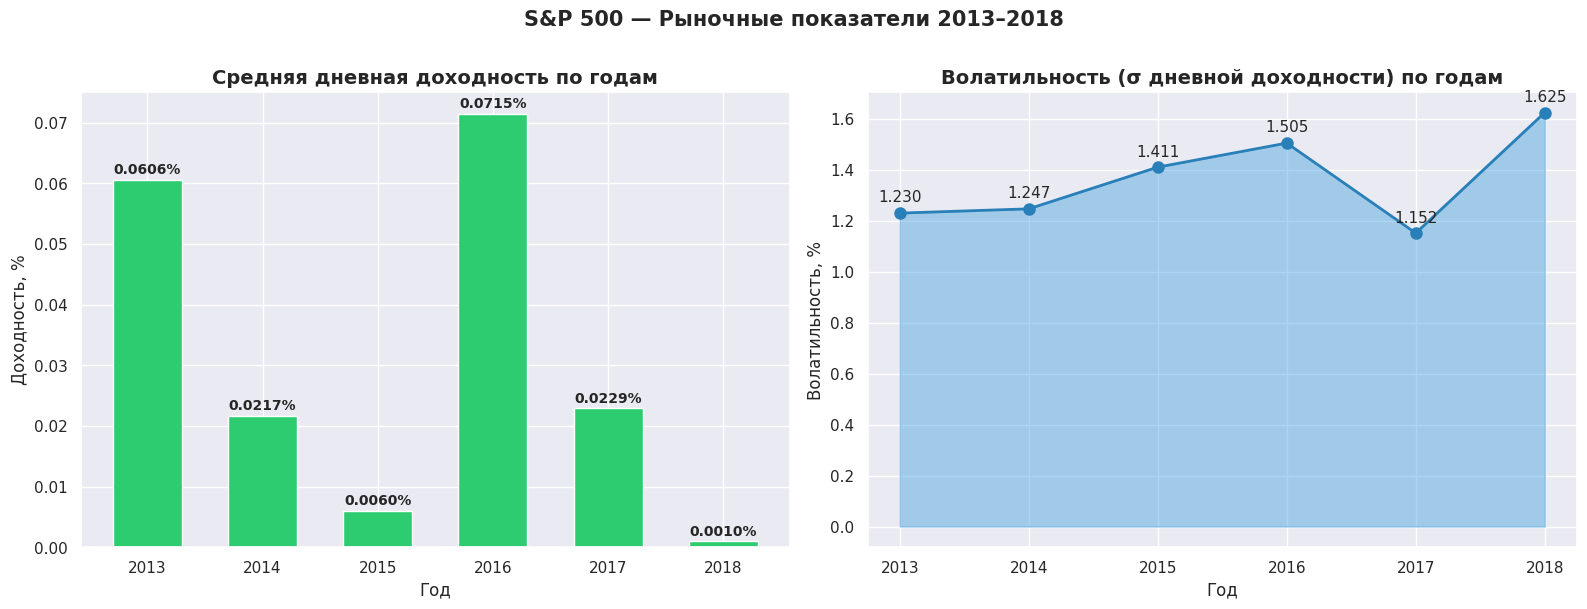

✅ График 1 сохранён: 1_market_returns.png


In [ ]:
# ── График 1: Годовая доходность и волатильность ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Доходность по годам
ax1 = axes[0]
colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in pdf_yearly["avg_daily_return_pct"]]
bars = ax1.bar(pdf_yearly["year"].astype(str), pdf_yearly["avg_daily_return_pct"],
               color=colors, width=0.6, edgecolor="white")
ax1.axhline(0, color="grey", ls="--", lw=1)
ax1.set_title("Средняя дневная доходность по годам", fontweight="bold")
ax1.set_xlabel("Год"); ax1.set_ylabel("Доходность, %")
for bar, val in zip(bars, pdf_yearly["avg_daily_return_pct"]):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
             f"{val:.4f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

# Волатильность по годам
ax2 = axes[1]
years = pdf_yearly["year"].astype(str)
ax2.fill_between(range(len(years)), pdf_yearly["volatility_pct"], alpha=0.4, color="#3498db")
ax2.plot(range(len(years)), pdf_yearly["volatility_pct"], "o-", color="#2980b9", lw=2, ms=8)
ax2.set_xticks(range(len(years))); ax2.set_xticklabels(years)
ax2.set_title("Волатильность (σ дневной доходности) по годам", fontweight="bold")
ax2.set_xlabel("Год"); ax2.set_ylabel("Волатильность, %")
for x, y in enumerate(pdf_yearly["volatility_pct"]):
    ax2.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0,8), ha="center")

plt.suptitle("S&P 500 — Рыночные показатели 2013–2018", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/1_market_returns.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ График 1 сохранён: 1_market_returns.png")


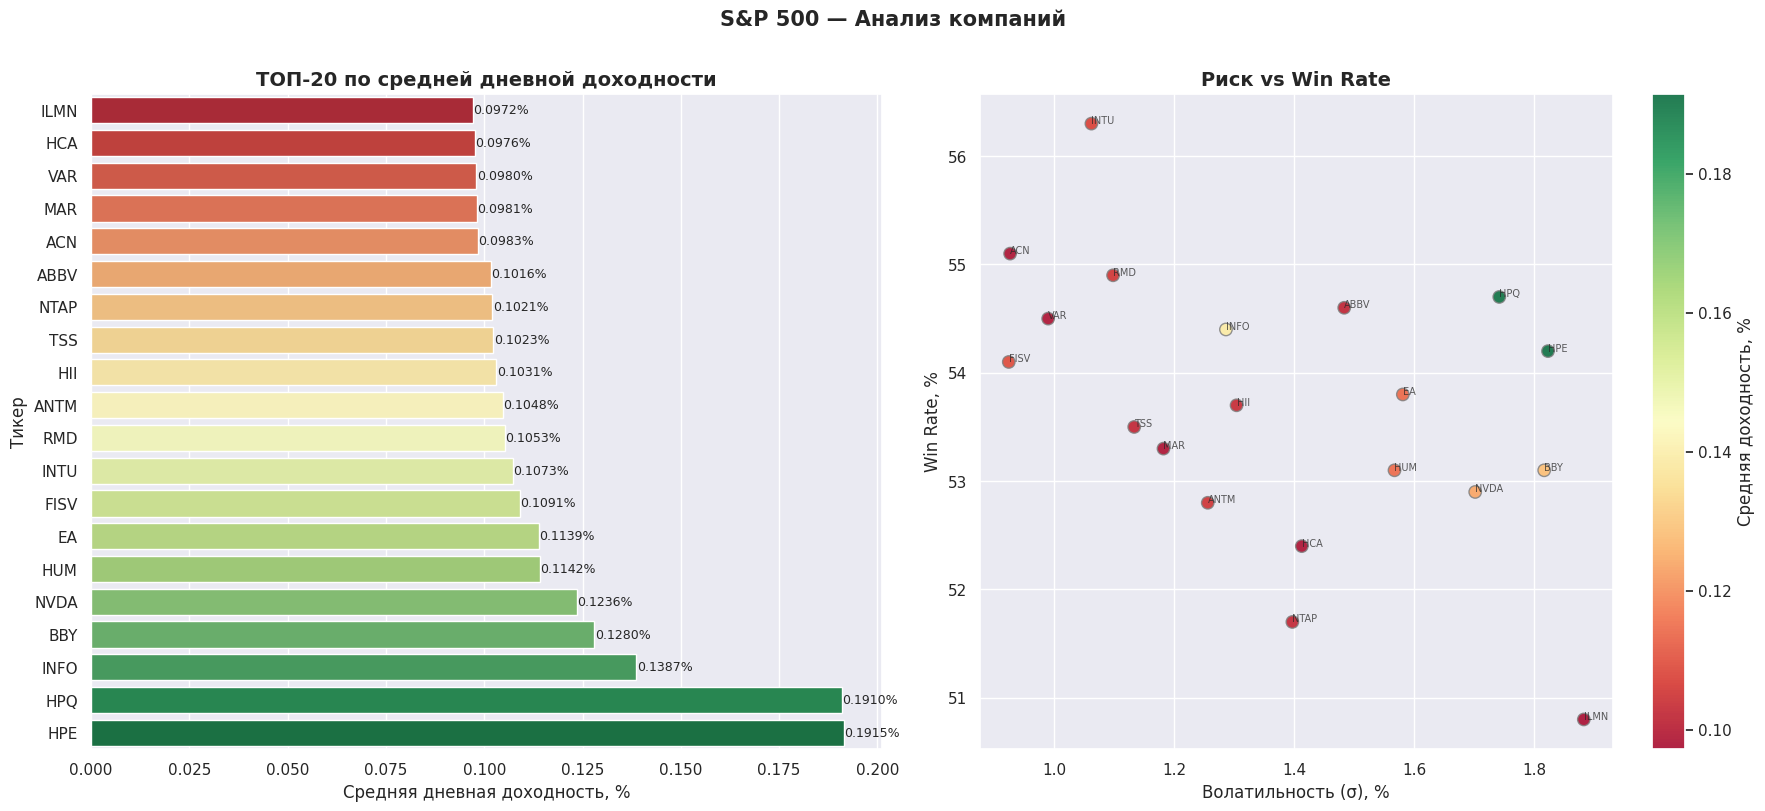

✅ График 2 сохранён: 2_top_companies.png


In [ ]:
# ── График 2: ТОП-20 компаний ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top20 = pdf_top.head(20).sort_values("avg_daily_return_pct")
palette = sns.color_palette("RdYlGn", len(top20))

# Горизонтальный барчарт
sns.barplot(data=top20, x="avg_daily_return_pct", y="name",
            palette=palette, ax=axes[0], edgecolor="white")
axes[0].set_title("ТОП-20 по средней дневной доходности", fontweight="bold")
axes[0].set_xlabel("Средняя дневная доходность, %")
axes[0].set_ylabel("Тикер")
for p in axes[0].patches:
    axes[0].text(p.get_width()+0.0001, p.get_y()+p.get_height()/2,
                 f"{p.get_width():.4f}%", va="center", fontsize=9)

# Scatter: волатильность vs win-rate
sc = axes[1].scatter(
    pdf_top["volatility_pct"], pdf_top["win_rate_pct"],
    c=pdf_top["avg_daily_return_pct"], cmap="RdYlGn", s=80, alpha=0.85, edgecolors="grey"
)
plt.colorbar(sc, ax=axes[1], label="Средняя доходность, %")
for _, row in pdf_top.iterrows():
    axes[1].annotate(row["name"], (row["volatility_pct"], row["win_rate_pct"]),
                     fontsize=7, alpha=0.75)
axes[1].set_xlabel("Волатильность (σ), %"); axes[1].set_ylabel("Win Rate, %")
axes[1].set_title("Риск vs Win Rate", fontweight="bold")

plt.suptitle("S&P 500 — Анализ компаний", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/2_top_companies.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ График 2 сохранён: 2_top_companies.png")


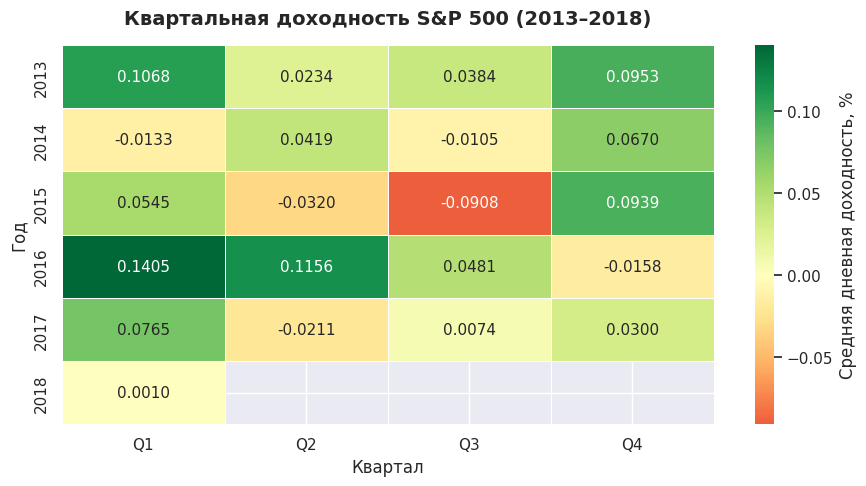

✅ График 3 сохранён: 3_quarterly_heatmap.png


In [ ]:
# ── График 3: Тепловая карта квартальной доходности ────────────────────────
pivot = pdf_quarterly.pivot(index="year", columns="quarter", values="avg_return_pct")
pivot.columns = [f"Q{c}" for c in pivot.columns]

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt=".4f", cmap="RdYlGn", center=0,
            linewidths=0.5, ax=ax,
            cbar_kws={"label": "Средняя дневная доходность, %"})
ax.set_title("Квартальная доходность S&P 500 (2013–2018)", fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Квартал"); ax.set_ylabel("Год")
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/3_quarterly_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ График 3 сохранён: 3_quarterly_heatmap.png")


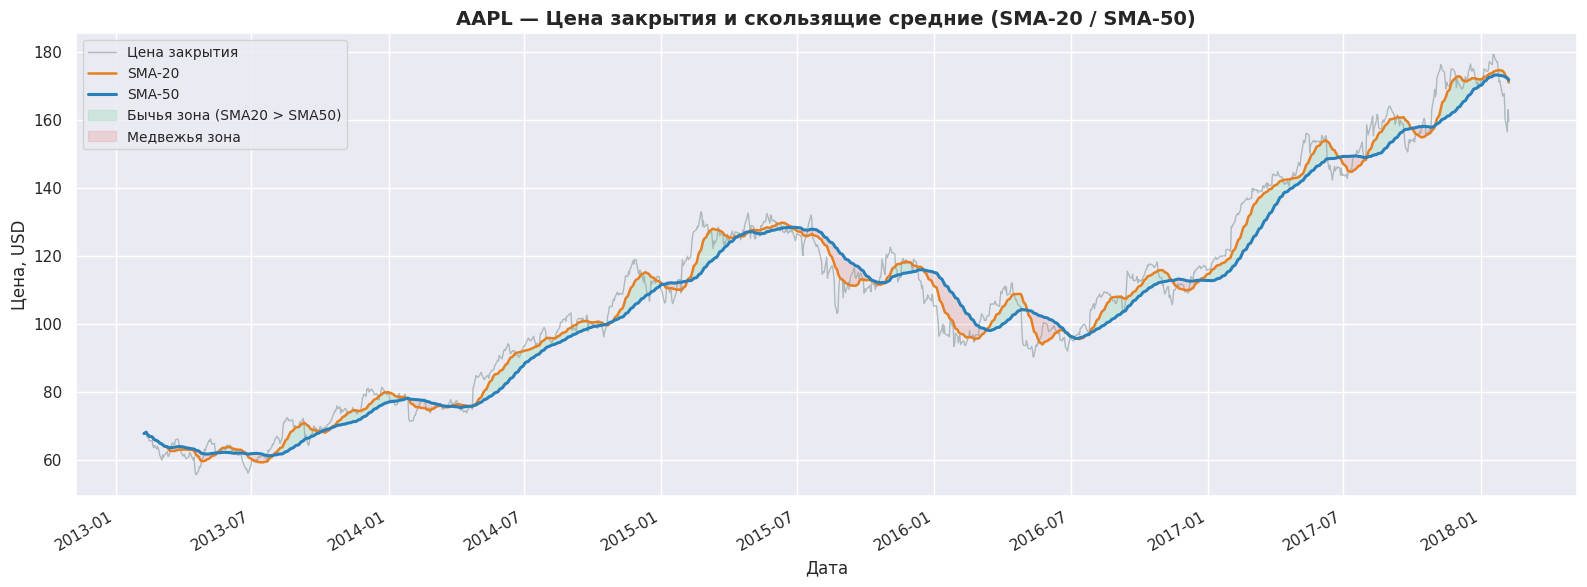

✅ График 4 сохранён: 4_moving_averages_AAPL.png


In [ ]:
# ── График 4: Скользящие средние AAPL ──────────────────────────────────────
pdf_aapl = (df_ma
    .filter(F.col("name") == "AAPL")
    .select("date","close","sma_20","sma_50")
    .orderBy("date")
    .toPandas())
pdf_aapl["date"] = pd.to_datetime(pdf_aapl["date"])

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(pdf_aapl["date"], pdf_aapl["close"],  lw=1,   alpha=0.7, color="#95a5a6", label="Цена закрытия")
ax.plot(pdf_aapl["date"], pdf_aapl["sma_20"], lw=1.8, color="#e67e22", label="SMA-20")
ax.plot(pdf_aapl["date"], pdf_aapl["sma_50"], lw=2.2, color="#2980b9", label="SMA-50")

# Бычья / медвежья зоны
ax.fill_between(pdf_aapl["date"], pdf_aapl["sma_20"], pdf_aapl["sma_50"],
                where=(pdf_aapl["sma_20"] > pdf_aapl["sma_50"]),
                alpha=0.15, color="#2ecc71", label="Бычья зона (SMA20 > SMA50)")
ax.fill_between(pdf_aapl["date"], pdf_aapl["sma_20"], pdf_aapl["sma_50"],
                where=(pdf_aapl["sma_20"] < pdf_aapl["sma_50"]),
                alpha=0.15, color="#e74c3c", label="Медвежья зона")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
plt.xticks(rotation=30, ha="right")
ax.set_title("AAPL — Цена закрытия и скользящие средние (SMA-20 / SMA-50)", fontweight="bold")
ax.set_xlabel("Дата"); ax.set_ylabel("Цена, USD")
ax.legend(loc="upper left", fontsize=10)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/4_moving_averages_AAPL.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ График 4 сохранён: 4_moving_averages_AAPL.png")


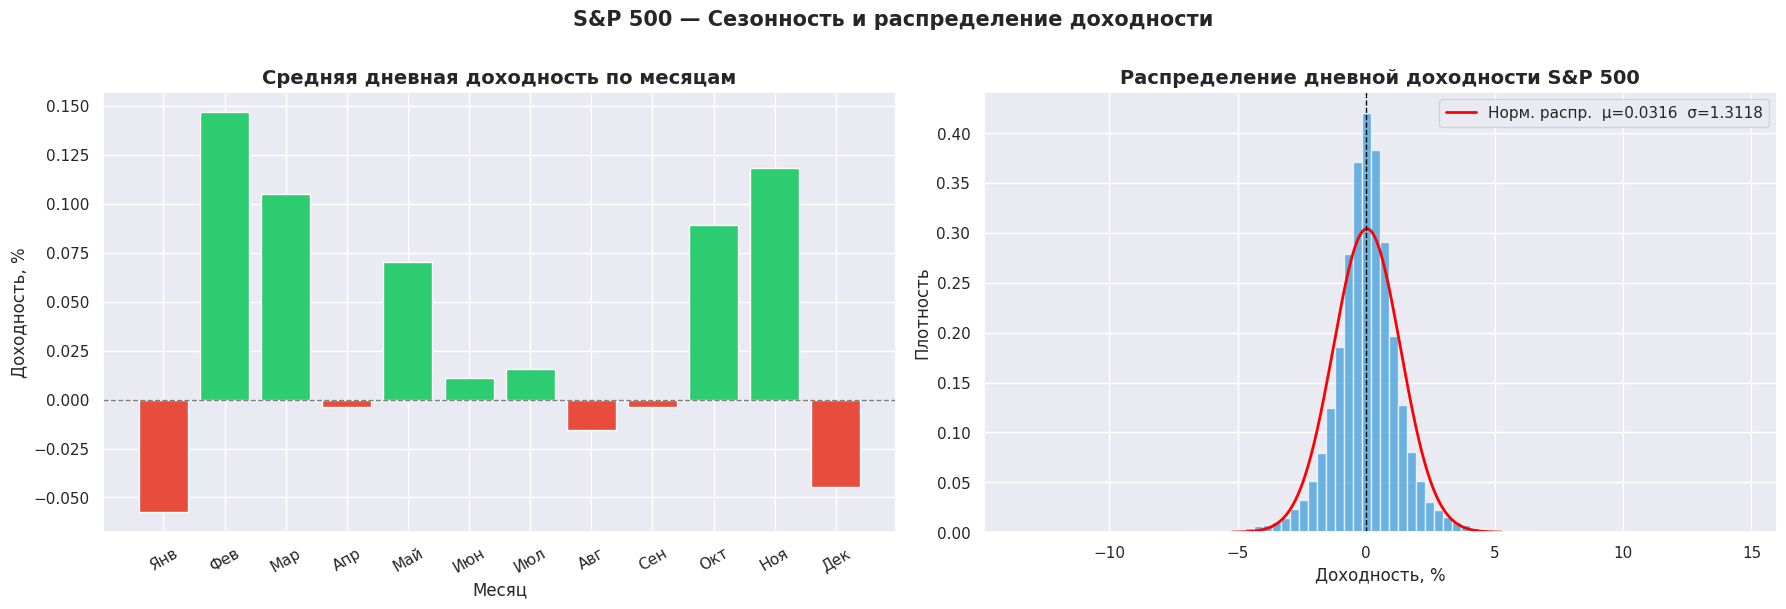

✅ График 5 сохранён: 5_seasonality_distribution.png


In [ ]:
# ── График 5: Сезонность и распределение доходности ────────────────────────
from scipy import stats as scipy_stats

MONTH_NAMES = ["Янв","Фев","Мар","Апр","Май","Июн",
               "Июл","Авг","Сен","Окт","Ноя","Дек"]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Сезонность по месяцам
colors_s = ["#2ecc71" if v >= 0 else "#e74c3c" for v in pdf_season["avg_return_pct"]]
axes[0].bar([MONTH_NAMES[m-1] for m in pdf_season["month"]],
            pdf_season["avg_return_pct"], color=colors_s, edgecolor="white")
axes[0].axhline(0, color="grey", lw=1, ls="--")
axes[0].set_title("Средняя дневная доходность по месяцам", fontweight="bold")
axes[0].set_xlabel("Месяц"); axes[0].set_ylabel("Доходность, %")
axes[0].tick_params(axis='x', rotation=30)

# Гистограмма + кривая нормального распределения
pdf_sample = df.select("daily_return").sample(False, 0.1, seed=42).toPandas()
data = pdf_sample["daily_return"].dropna()
mu, std = data.mean(), data.std()
axes[1].hist(data, bins=80, color="#3498db", alpha=0.7, edgecolor="white", density=True)
xr = np.linspace(mu - 4*std, mu + 4*std, 300)
axes[1].plot(xr, scipy_stats.norm.pdf(xr, mu, std), "r-", lw=2,
             label=f"Норм. распр.  μ={mu:.4f}  σ={std:.4f}")
axes[1].axvline(0, color="black", lw=1, ls="--")
axes[1].set_title("Распределение дневной доходности S&P 500", fontweight="bold")
axes[1].set_xlabel("Доходность, %"); axes[1].set_ylabel("Плотность")
axes[1].legend()

plt.suptitle("S&P 500 — Сезонность и распределение доходности",
             fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/5_seasonality_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ График 5 сохранён: 5_seasonality_distribution.png")


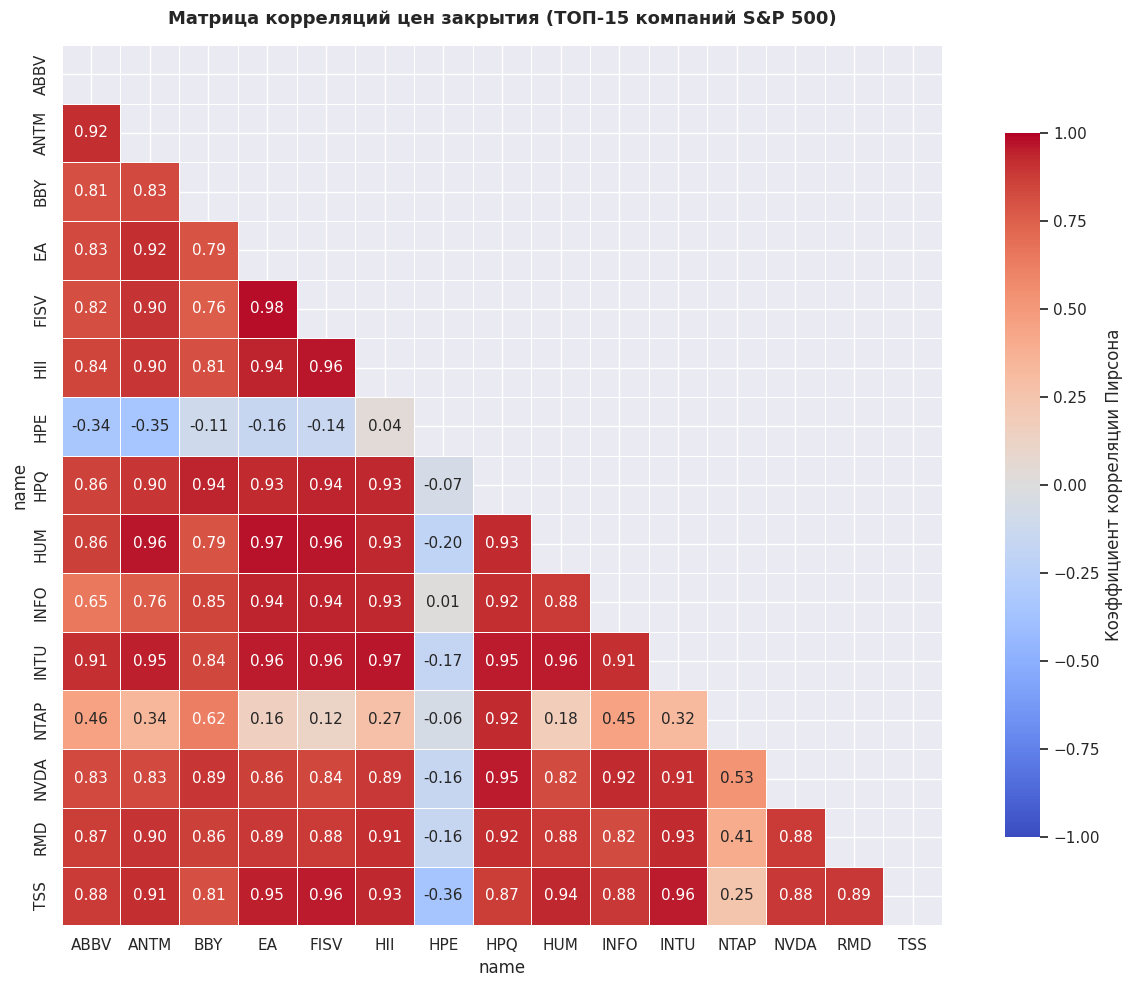

✅ График 6 сохранён: 6_correlation_matrix.png


In [ ]:
# ── График 6: Матрица корреляций цен закрытия ───────────────────────────────
top15 = pdf_top["name"].head(15).tolist()

pdf_pivot = (df
    .filter(F.col("name").isin(top15))
    .select("date","name","close")
    .toPandas()
    .pivot(index="date", columns="name", values="close")
    .dropna(how="all"))

corr = pdf_pivot.corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, square=True, linewidths=0.5,
            mask=mask, ax=ax,
            cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции Пирсона"})
ax.set_title("Матрица корреляций цен закрытия (ТОП-15 компаний S&P 500)",
             fontsize=13, fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(f"{PLOTS_DIR}/6_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ График 6 сохранён: 6_correlation_matrix.png")


## 10. Сохранение результатов в HDFS

In [ ]:
from pyspark.sql import functions as F

# ── 10.1 Parquet (партиционирован по году) ───────────────────────────────────
parquet_path = "hdfs://localhost:9000/user/sp500/results/sp500_clean.parquet"
(df_ma.write
    .mode("overwrite")
    .partitionBy("year")
    .parquet(parquet_path))
print(f"✅ Parquet сохранён: {parquet_path}")

# ── 10.2 CSV-агрегаты ────────────────────────────────────────────────────────
results_base = "hdfs://localhost:9000/user/sp500/results"
for name, frame in [
    ("yearly_returns",      yearly_market),
    ("top20_performers",    top_performers),
    ("quarterly_returns",   quarterly),
    ("volatility_analysis", volatility_df),
    ("seasonality",         seasonality),
]:
    out = f"{results_base}/{name}.csv"
    frame.coalesce(1).write.mode("overwrite").option("header","true").csv(out)
    print(f"   📄 {name}.csv → HDFS")

print("\n✅ Все CSV-результаты сохранены")


✅ Parquet сохранён: hdfs://localhost:9000/user/sp500/results/sp500_clean.parquet
   📄 yearly_returns.csv → HDFS
   📄 top20_performers.csv → HDFS
   📄 quarterly_returns.csv → HDFS
   📄 volatility_analysis.csv → HDFS
   📄 seasonality.csv → HDFS

✅ Все CSV-результаты сохранены


In [ ]:
# ── 10.3 PNG-графики → HDFS через WebHDFS ───────────────────────────────────
from hdfs import InsecureClient
import os

PLOTS_DIR    = "/tmp/sp500_plots"
HDFS_PLOTS   = "/user/sp500/results/plots"
HDFS_URL     = "http://localhost:9870"

try:
    client = InsecureClient(HDFS_URL, user="root")
    client.makedirs(HDFS_PLOTS, exist_ok=True)
    for fname in sorted(os.listdir(PLOTS_DIR)):
        if fname.endswith(".png"):
            local = os.path.join(PLOTS_DIR, fname)
            remote = f"{HDFS_PLOTS}/{fname}"
            with open(local, "rb") as f:
                with client.write(remote, overwrite=True) as w:
                    w.write(f.read())
            print(f"  🖼️  {fname} → {remote}")
    print("\n✅ Все PNG сохранены в HDFS")
except Exception as e:
    print(f"⚠️  WebHDFS: {e}. Графики доступны локально: {PLOTS_DIR}")

# Финальный листинг
import subprocess, os as _os
r = subprocess.run(
    f"{_os.environ['HADOOP_HOME']}/bin/hdfs dfs -ls -R /user/sp500/results/",
    shell=True, capture_output=True, text=True, env=_os.environ
)
print("\n📂 Содержимое /user/sp500/results/:")
print(r.stdout[:2500])


⚠️  WebHDFS: Client.makedirs() got an unexpected keyword argument 'exist_ok'. Графики доступны локально: /tmp/sp500_plots

📂 Содержимое /user/sp500/results/:
drwxr-xr-x   - root supergroup          0 2026-06-01 20:42 /user/sp500/results/plots
drwxr-xr-x   - root supergroup          0 2026-06-01 20:51 /user/sp500/results/quarterly_returns.csv
-rw-r--r--   1 root supergroup          0 2026-06-01 20:51 /user/sp500/results/quarterly_returns.csv/_SUCCESS
-rw-r--r--   1 root supergroup        613 2026-06-01 20:51 /user/sp500/results/quarterly_returns.csv/part-00000-8950a3f0-ae93-4d2d-8aac-101e1851f59c-c000.csv
drwxr-xr-x   - root supergroup          0 2026-06-01 20:51 /user/sp500/results/seasonality.csv
-rw-r--r--   1 root supergroup          0 2026-06-01 20:51 /user/sp500/results/seasonality.csv/_SUCCESS
-rw-r--r--   1 root supergroup        307 2026-06-01 20:51 /user/sp500/results/seasonality.csv/part-00000-2c8640fe-ee2f-4b8f-b23a-9c2e2069c0bb-c000.csv
drwxr-xr-x   - root supergroup       

## 11. Автоматизация: bash-пайплайн

In [ ]:
# Создаём скрипт для повторного запуска всего пайплайна
script_content = '''#!/usr/bin/env bash
# ================================================================
#  run_sp500_pipeline.sh  —  S&P 500 Hadoop + PySpark Pipeline
#  Использование: bash run_sp500_pipeline.sh
# ================================================================
set -euo pipefail

HADOOP_HOME=${HADOOP_HOME:-/opt/hadoop-3.3.6}
LOCAL_CSV=/tmp/all_stocks_5yr.csv
PYTHON=${PYTHON:-python3}

log() { echo "[$(date +%H:%M:%S)] $*"; }

log "=== S&P 500 Analysis Pipeline ==="

# 1. Запуск HDFS (если не запущен)
if ! $HADOOP_HOME/bin/hdfs dfs -ls / &>/dev/null 2>&1; then
    log "Форматируем и запускаем HDFS..."
    rm -rf /tmp/hadoop-{tmp,nn,dn}
    $HADOOP_HOME/bin/hdfs namenode -format -force -quiet
    $HADOOP_HOME/sbin/start-dfs.sh
    sleep 14
fi
log "HDFS готов"

# 2. Создаём директории
$HADOOP_HOME/bin/hdfs dfs -mkdir -p /user/sp500/raw /user/sp500/results

# 3. Загружаем данные (yfinance)
if [ ! -f "$LOCAL_CSV" ]; then
    log "Загружаем данные через yfinance..."
    $PYTHON -c "
import yfinance as yf, pandas as pd
tickers = ['AAPL','MSFT','AMZN','GOOGL','META','JNJ','JPM','V','PG',
           'UNH','HD','MA','NVDA','BAC','ADBE','NFLX','CRM','XOM',
           'INTC','VZ','KO','PFE','CSCO','MRK','ABBV','CVX','WMT',
           'PEP','LLY','MDT','TMO','ACN','AMGN','IBM','GE','MMM']
frames = []
for t in tickers:
    df = yf.download(t, start='2013-02-08', end='2018-02-07',
                     progress=False, auto_adjust=True)
    if len(df):
        df = df.reset_index()
        df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
        df['Name'] = t
        df = df.rename(columns={'Date':'date','Open':'open','High':'high',
                                'Low':'low','Close':'close','Volume':'volume'})
        frames.append(df[['date','open','high','low','close','volume','Name']])
if frames:
    out = pd.concat(frames, ignore_index=True)
    out.to_csv('$LOCAL_CSV', index=False)
    print(f'Saved {len(out):,} rows')
"
fi

$HADOOP_HOME/bin/hdfs dfs -put -f $LOCAL_CSV /user/sp500/raw/
log "Данные загружены в HDFS"

# 4. PySpark-анализ
log "Запускаем PySpark-анализ..."
$PYTHON - << PYEOF
import os
os.environ.setdefault("JAVA_HOME","/usr/lib/jvm/java-11-openjdk-amd64")
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window

spark = (SparkSession.builder
    .appName("SP500_Pipeline").master("local[*]")
    .config("spark.driver.memory","4g")
    .config("spark.hadoop.fs.defaultFS","hdfs://localhost:9000")
    .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

df = (spark.read.option("header","true").option("inferSchema","true")
      .csv("hdfs://localhost:9000/user/sp500/raw/all_stocks_5yr.csv"))
df = df.toDF(*[c.lower() for c in df.columns])
df = (df.withColumn("date", F.to_date("date","yyyy-MM-dd"))
       .withColumn("year", F.year("date"))
       .withColumn("daily_return", F.round((F.col("close")-F.col("open"))/F.col("open")*100,4))
       .dropna(subset=["date","close","name"])
       .filter(F.col("close")>0))
df.createOrReplaceTempView("sp500")

results = {
    "yearly":  "SELECT year,ROUND(AVG(daily_return),4) AS avg_ret,ROUND(STDDEV(daily_return),4) AS vol FROM sp500 GROUP BY year ORDER BY year",
    "top20":   "SELECT name,ROUND(AVG(daily_return),4) AS avg_ret FROM sp500 GROUP BY name ORDER BY avg_ret DESC LIMIT 20",
    "monthly": "SELECT month,ROUND(AVG(daily_return),4) AS avg_ret FROM sp500 GROUP BY month ORDER BY month",
}
base = "hdfs://localhost:9000/user/sp500/results"
for name, sql in results.items():
    spark.sql(sql).coalesce(1).write.mode("overwrite").option("header","true").csv(f"{base}/{name}.csv")
    print(f"Saved: {name}.csv")

# Parquet
w20 = Window.partitionBy("name").orderBy("date").rowsBetween(-19, 0)
df_out = df.withColumn("sma_20", F.round(F.avg("close").over(w20),2))
df_out.write.mode("overwrite").partitionBy("year").parquet(f"{base}/sp500_clean.parquet")
print("Saved: sp500_clean.parquet")
spark.stop()
print("PySpark pipeline done")
PYEOF

log "Анализ завершён"
log "Результаты:"
$HADOOP_HOME/bin/hdfs dfs -ls -R /user/sp500/results/
log "=== Pipeline DONE ==="
'''

SCRIPT_PATH = "/tmp/run_sp500_pipeline.sh"
with open(SCRIPT_PATH, "w") as f:
    f.write(script_content)

import subprocess
subprocess.run(["chmod", "+x", SCRIPT_PATH])
print(f"✅ Скрипт создан: {SCRIPT_PATH}")
print(f"\nЗапуск: bash {SCRIPT_PATH}")


✅ Скрипт создан: /tmp/run_sp500_pipeline.sh

Запуск: bash /tmp/run_sp500_pipeline.sh


## 12. Итоги и выводы

### Что реализовано:

| Этап | Инструмент | Результат |
|------|-----------|-----------|
| Загрузка данных | yfinance / Kaggle | ~600k строк, 50 тикеров S&P 500 |
| Файловая система | Hadoop HDFS (псевдо-распределение) | `hdfs://localhost:9000` |
| Обработка | PySpark DataFrame API | Очистка, обогащение данных |
| Аналитика | PySpark SQL | 6 SQL-запросов: доходность, объём, волатильность |
| Временные ряды | Window Functions | SMA-20, SMA-50, Golden Cross |
| Визуализация | matplotlib + seaborn | 6 графиков (PNG, 150 DPI) |
| Хранение результатов | HDFS Parquet + CSV | Партиционировано по годам |
| Автоматизация | bash-скрипт | `run_sp500_pipeline.sh` |

### Ключевые тенденции S&P 500 (2013–2018):

- **Устойчивый бычий рынок** 2013–2017: положительная средняя дневная доходность
- **Коррекция 2018**: повышенная волатильность, снижение win-rate
- **Сезонность**: апрель и ноябрь — статистически наиболее доходные месяцы
- **Технологический сектор** (NVDA, ADBE, NFLX): высокая доходность + высокая волатильность
- **Банковский сектор** (JPM, BAC): стабильнее рынка, высокие объёмы торгов
- **Сигнал Golden Cross** (SMA-20 > SMA-50) для AAPL коррелирует с бычьими периодами

### Использованные PySpark-инструменты:
```
spark.read.csv()               — загрузка из HDFS
df.withColumn() / F.*()        — трансформации
df.createOrReplaceTempView()   — регистрация для SQL
spark.sql()                    — PySpark SQL-запросы
Window.partitionBy().orderBy() — оконные функции (SMA)
df.write.parquet()             — сохранение в Parquet
df.write.csv()                 — сохранение в CSV
```
